In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\abhis\Downloads\home-credit-default-risk\mortgage_risk_project\data\raw\application_train.csv")

print(df.shape)
#print(df.dtypes)
#print(df.isnull().sum().sort_values(ascending=False).head(20))
#print(df['TARGET'].value_counts())  # 0 = repaid, 1 = defaulted

(307511, 122)


In [5]:
print(df.dtypes)

SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object


In [6]:
print(df.isnull().sum().sort_values(ascending=False).head(20))

COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
NONLIVINGAPARTMENTS_MEDI    213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_AVG        210199
LIVINGAPARTMENTS_MEDI       210199
FLOORSMIN_AVG               208642
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
YEARS_BUILD_MEDI            204488
YEARS_BUILD_MODE            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
LANDAREA_AVG                182590
dtype: int64


In [7]:
print(df['TARGET'].value_counts())  # 0 = repaid, 1 = defaulted

TARGET
0    282686
1     24825
Name: count, dtype: int64


In [8]:
# Check missing % for key columns
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_pct[missing_pct > 0].head(30))

# EXT_SOURCE scores (credit bureau scores — very important)
# Flag missing as a separate binary column, then fill with median
for col in ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']:
    df[f'{col}_MISSING'] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(df[col].median())

# OCCUPATION_TYPE — fill with 'Unknown'
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')

# DAYS_EMPLOYED anomaly fix (365243 is a placeholder for unemployed)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df['DAYS_EMPLOYED_MISSING'] = df['DAYS_EMPLOYED'].isnull().astype(int)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].fillna(df['DAYS_EMPLOYED'].median())

COMMONAREA_MEDI             69.872297
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MODE              67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_MEDI            66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_AVG             66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_MODE               59.376738
LANDAREA_AVG                59.376738
BASEMENTAREA_MEDI           58.515956
BASEMENTAREA_AVG            58.515956
BASEMENTAREA_MODE           58.515956
EXT_SOURCE_1                56.381073
NONLIVINGAREA_MODE          55.179164
NONLIVINGAREA_AVG           55.179164
NONLIVINGARE

In [9]:
# Feature 1: How much credit relative to income?
# High ratio = risky borrower
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

# Feature 2: How much is the annual repayment vs income?
# High ratio = borrower may struggle to repay monthly
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# Feature 3: How long have they been employed relative to their age?
# Convert days to years (values are negative in dataset = days before application)
df['DAYS_EMPLOYED_RATIO'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']

In [10]:
df['INCOME_BAND'] = pd.cut(
    df['AMT_INCOME_TOTAL'],
    bins=[0, 100000, 200000, 350000, float('inf')],
    labels=['Low (<100K)', 'Mid (100–200K)', 'High (200–350K)', 'Very High (350K+)']
)

In [12]:
import os
os.makedirs('data/cleaned', exist_ok=True)   # ← add this line

plt.savefig('data/cleaned/eda_plots.png', dpi=150)
plt.show()

<Figure size 640x480 with 0 Axes>

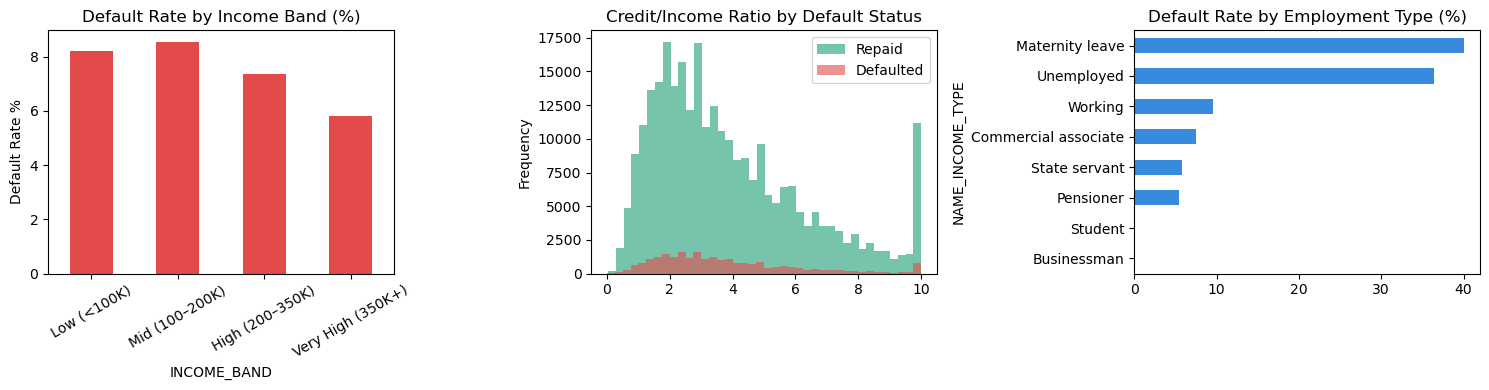

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Default rate by income band
default_by_income = df.groupby('INCOME_BAND', observed=False)['TARGET'].mean() * 100
default_by_income.plot(kind='bar', ax=axes[0], color='#E24B4A')
axes[0].set_title('Default Rate by Income Band (%)')
axes[0].set_ylabel('Default Rate %')
axes[0].tick_params(axis='x', rotation=30)

# Plot 2: Credit Income Ratio distribution by target
df[df['TARGET']==0]['CREDIT_INCOME_RATIO'].clip(0,10).plot(
    kind='hist', bins=40, alpha=0.6, ax=axes[1], label='Repaid', color='#1D9E75')
df[df['TARGET']==1]['CREDIT_INCOME_RATIO'].clip(0,10).plot(
    kind='hist', bins=40, alpha=0.6, ax=axes[1], label='Defaulted', color='#E24B4A')
axes[1].set_title('Credit/Income Ratio by Default Status')
axes[1].legend()

# Plot 3: Default rate by name_income_type
default_by_type = df.groupby('NAME_INCOME_TYPE', observed=True)['TARGET'].mean().sort_values() * 100
default_by_type.plot(kind='barh', ax=axes[2], color='#378ADD')
axes[2].set_title('Default Rate by Employment Type (%)')

plt.tight_layout()
plt.savefig('data/cleaned/eda_plots.png', dpi=150)
plt.show()

In [14]:
import sqlite3

# Select the columns you'll use in SQL + Power BI
cols_to_keep = [
    'SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'OCCUPATION_TYPE', 'REGION_POPULATION_RELATIVE', 'AMT_INCOME_TOTAL',
    'AMT_CREDIT', 'AMT_ANNUITY', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING',
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'DAYS_EMPLOYED_RATIO',
    'INCOME_BAND'
]

df_clean = df[cols_to_keep].copy()

# Convert DAYS_BIRTH to age in years
df_clean['AGE_YEARS'] = abs(df_clean['DAYS_BIRTH']) / 365

# Export to SQLite
conn = sqlite3.connect('data/cleaned/mortgage.db')
df_clean.to_sql('mortgage_clean', conn, if_exists='replace', index=False)
conn.close()

# Also save as CSV for Power BI
df_clean.to_csv('data/cleaned/mortgage_clean.csv', index=False)

print(f"Exported {len(df_clean):,} rows to SQLite and CSV")

Exported 307,511 rows to SQLite and CSV
